# Dataset de fractura de pozos de hidrocarburos

## Proyecto Final — Pre-entrega 2

**Integrantes:** Franco Malacalza · Martín Gerbaldo · Carolina Bailón

**Curso:** EnergIA Digital 2026 — Ciencia de Datos

---

## El tema

Un pozo no convencional no produce por sí solo: la roca de Vaca Muerta tiene el petróleo atrapado
adentro y hay que agrietarla. Para eso se perfora un tramo horizontal de varios kilómetros y se
bombea agua con arena a alta presión, en decenas de etapas sucesivas. La arena queda trabando las
fracturas para que no se cierren, y por ahí fluye el petróleo.

Ese conjunto de decisiones —cuán largo es el tramo horizontal, cuántas etapas, cuánta arena y
cuánta agua— es el **diseño de completación**, y concentra buena parte del costo del pozo. La
operadora lo define antes de saber cuánto va a producir, y es irreversible: una vez bombeada, la
arena no se recupera.

## El objetivo

Entender **cómo se diseñan hoy estos pozos y cómo cambió ese diseño en la última década**, y dejar
un dataset limpio que permita, más adelante, estimar la producción esperada a partir del diseño.

## El dataset

| Fuente | Contenido | Registros |
|---|---|---|
| Secretaría de Energía — Datos de fractura de pozos (Adjunto IV) | Una fila por operación de fractura declarada | 4.890 |

http://datos.energia.gob.ar/dataset/datos-de-fractura-de-pozos-adjunto-iv

## Cómo está organizado este notebook

Sigue la estructura de la guía de la cursada:

- **Parte 1 — Análisis exploratorio** (puntos 1 a 12): conocer el dataset sin modificarlo.
- **Parte 2 — Transformación y limpieza** (puntos 13 a 17): corregir lo que el análisis detectó.
- **Parte 3 — Feature engineering** (punto 18): crear variables nuevas.

---

# Parte 1: Análisis Exploratorio de Datos (EDA)

# 1. Conociendo el Dataset

Las primeras preguntas: cuántas filas y columnas hay, qué representa cada fila, qué tipo de dato
tiene cada variable, si hay faltantes y si hay registros repetidos.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

HOY = pd.Timestamp.today().normalize()

# El CSV está guardado en el repositorio. Se intenta primero la copia local,
# así el notebook corre sin conexión; si no aparece —por ejemplo al abrirlo en
# Colab— se lee directamente del repositorio por su URL.
URL_REPO = ("https://raw.githubusercontent.com/FrancoMalacalza01/"
            "preentrega-data-science/main/data/fractura_adjunto_iv.csv")
CANDIDATOS = [Path("../data/fractura_adjunto_iv.csv"),
              Path("data/fractura_adjunto_iv.csv")]

ruta_local = next((p for p in CANDIDATOS if p.exists()), None)
origen = ruta_local if ruta_local is not None else URL_REPO
PROC_DIR = (ruta_local.parent if ruta_local is not None else Path("data")) / "processed"

df = pd.read_csv(origen, low_memory=False)
print(f"Origen: {origen}")

Origen: ../data/fractura_adjunto_iv.csv


In [2]:
# ¿Cuántas filas y columnas tiene?
print(f"Filas y columnas: {df.shape}")
df.head()

Filas y columnas: (4890, 30)


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.00,3,Punzado,0.00,0.00,"2,718.20",0.00,"10,190.00","10,897.00",2019-04-20,2019-04-30,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.00,1,Punzado,0.00,0.00,600.00,0.00,"9,250.00","10,251.00",2018-11-02,2018-11-03,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,437.30",18,Tapón disparo,"3,761.37",536.85,"25,768.30",0.00,"15,000.00","32,000.00",2017-11-19,2017-12-14,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,518.30",19,Tapón disparo,"3,903.70",558.23,"27,398.37",0.00,"11,348.00","32,000.00",2017-11-21,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,482.30",19,Tapón disparo,"3,949.02",569.92,"27,157.60",0.00,"11,076.00","32,000.00",2017-11-18,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


In [3]:
# ¿Qué tipo de dato tiene cada variable? ¿Cuántos no nulos?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4890 non-null   int64  
 1   idpozo                        4890 non-null   int64  
 2   sigla                         4890 non-null   str    
 3   cuenca                        4890 non-null   str    
 4   areapermisoconcesion          4890 non-null   str    
 5   yacimiento                    4890 non-null   str    
 6   formacion_productiva          4890 non-null   str    
 7   tipo_reservorio               4855 non-null   str    
 8   subtipo_reservorio            3916 non-null   str    
 9   longitud_rama_horizontal_m    4890 non-null   float64
 10  cantidad_fracturas            4890 non-null   int64  
 11  tipo_terminacion              4890 non-null   str    
 12  arena_bombeada_nacional_tn    4890 non-null   float64
 13  arena_bombeada

Dos cosas para anotar del `info()`:

- **Las fechas están cargadas como texto.** `fecha_inicio_fractura`, `fecha_fin_fractura` y
  `fecha_data` figuran como `object`. Hay que convertirlas en la Parte 2 para poder operar con ellas.
- **Casi no hay nulos**: solo tres columnas tienen menos de 4.890 valores no nulos.

In [4]:
# ¿Existen registros duplicados?
print(f"Filas exactamente duplicadas: {df.duplicated().sum()}")

# ¿Y columnas que repitan la misma información?
columnas_duplicadas = df.columns[df.T.duplicated()]
print(f"Columnas con información idéntica a otra: {list(columnas_duplicadas)}")

for col in columnas_duplicadas:
    gemelas = [c for c in df.columns if c != col and df[c].equals(df[col])]
    print(f"  {col} es idéntica a {gemelas}")

Filas exactamente duplicadas: 0


Columnas con información idéntica a otra: ['mes', 'anio']
  mes es idéntica a ['mes_if']
  anio es idéntica a ['anio_if']


> **Hallazgo — hay columnas redundantes.**
>
> No hay ninguna fila repetida, pero sí **dos pares de columnas que contienen exactamente lo
> mismo**: `mes` repite a `mes_if` y `anio` repite a `anio_if`. Son el mes y el año de la fecha de
> inicio de la fractura, guardados dos veces.
>
> No es un error grave, pero conviene saberlo: si más adelante usáramos las cuatro como variables
> distintas, estaríamos contando la misma información dos veces.

# 2. Identificación de las variables

Clasificamos las 30 columnas según su rol: identificadores, categóricas, numéricas, temporales y
texto descriptivo.

| Variable | Significado | Tipo |
|---|---|---|
| `id_base_fractura_adjiv` | Identificador del registro de fractura | Identificador |
| `idpozo` | Identificador del pozo | Identificador |
| `sigla` | Nombre técnico del pozo según la operadora | Texto |
| `cuenca` | Cuenca petrolera | Categórica |
| `areapermisoconcesion` | Área de concesión | Categórica |
| `yacimiento` | Yacimiento | Categórica |
| `formacion_productiva` | Formación geológica objetivo | Categórica |
| `tipo_reservorio` | Convencional / No convencional | Categórica |
| `subtipo_reservorio` | Shale / Tight | Categórica |
| `tipo_terminacion` | Técnica de terminación del pozo | Categórica |
| `empresa_informante` | Operadora que declara | Categórica |
| `longitud_rama_horizontal_m` | Largo del tramo horizontal, en metros | Numérica |
| `cantidad_fracturas` | Etapas de fractura ejecutadas | Numérica |
| `arena_bombeada_nacional_tn` | Arena nacional bombeada, en toneladas | Numérica |
| `arena_bombeada_importada_tn` | Arena importada bombeada, en toneladas | Numérica |
| `agua_inyectada_m3` | Agua inyectada, en metros cúbicos | Numérica |
| `co2_inyectado_m3` | CO2 inyectado, en metros cúbicos | Numérica |
| `presion_maxima_psi` | Presión máxima alcanzada | Numérica |
| `potencia_equipos_fractura_hp` | Potencia de los equipos | Numérica |
| `fecha_inicio_fractura`, `fecha_fin_fractura`, `fecha_data` | Fechas de la operación y de la carga | Temporal |
| `anio_if`, `mes_if`, `anio_ff`, `mes_ff`, `anio_carga`, `mes_carga`, `mes`, `anio` | Descomposición de las fechas | Temporal |

**No existe una columna `provincia`.** La ubicación se maneja con `cuenca`, `yacimiento` y
`areapermisoconcesion`.

In [5]:
IDENTIFICADORES = ["id_base_fractura_adjiv", "idpozo"]
TEXTO = ["sigla"]
CATEGORICAS = ["cuenca", "areapermisoconcesion", "yacimiento", "formacion_productiva",
               "tipo_reservorio", "subtipo_reservorio", "tipo_terminacion", "empresa_informante"]
NUMERICAS = ["longitud_rama_horizontal_m", "cantidad_fracturas",
             "arena_bombeada_nacional_tn", "arena_bombeada_importada_tn",
             "agua_inyectada_m3", "co2_inyectado_m3",
             "presion_maxima_psi", "potencia_equipos_fractura_hp"]
TEMPORALES = ["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data",
              "anio_if", "mes_if", "anio_ff", "mes_ff", "anio_carga", "mes_carga", "mes", "anio"]

resumen = pd.Series({
    "identificadores": len(IDENTIFICADORES),
    "texto": len(TEXTO),
    "categóricas": len(CATEGORICAS),
    "numéricas": len(NUMERICAS),
    "temporales": len(TEMPORALES),
})
print(resumen.to_string())
print(f"\nTotal clasificadas: {resumen.sum()} de {df.shape[1]} columnas")

identificadores     2
texto               1
categóricas         8
numéricas           8
temporales         11

Total clasificadas: 30 de 30 columnas


# 3. ¿Nuestros datos están completos?

Los faltantes pueden modificar promedios, conteos y gráficos, así que hay que saber dónde están y
cuánto pesan antes de sacar conclusiones.

In [6]:
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "%": (df.isnull().mean() * 100).round(2),
})
nulos[nulos["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,%
subtipo_reservorio,974,19.92
potencia_equipos_fractura_hp,51,1.04
tipo_reservorio,35,0.72


Solo tres columnas tienen faltantes, y una sola es significativa: `subtipo_reservorio` con casi el
20%. Las otras dos rondan el 1%.

**Pero los nulos no son el problema real de este dataset.** Hay columnas numéricas llenas de ceros,
y un cero puede significar dos cosas muy distintas: que la medición dio cero, o que nadie cargó el
dato. Conviene mirarlos.

In [7]:
ceros = pd.DataFrame({
    "ceros": [(df[c] == 0).sum() for c in NUMERICAS],
    "%": [round((df[c] == 0).mean() * 100, 1) for c in NUMERICAS],
}, index=NUMERICAS).sort_values("%", ascending=False)
ceros

,ceros,%
co2_inyectado_m3,4731,96.70
arena_bombeada_importada_tn,2348,48.00
longitud_rama_horizontal_m,2054,42.00
arena_bombeada_nacional_tn,1565,32.00
agua_inyectada_m3,305,6.20
potencia_equipos_fractura_hp,154,3.10
presion_maxima_psi,78,1.60
cantidad_fracturas,0,0.00


> **Hallazgo — los ceros son el problema, no los nulos.**
>
> `co2_inyectado_m3` vale cero en el 96,7% de los registros, y `longitud_rama_horizontal_m` en el
> 42%. Un cero en longitud de rama no es un dato faltante: **es un pozo vertical**, que no tiene
> tramo horizontal. Esto lo retomamos en el punto 7.

# 4. Registros duplicados

Ya vimos que no hay filas exactamente duplicadas. Pero puede haber varios registros del mismo pozo,
que es otra cosa: hay que revisar por identificador.

In [8]:
total_filas = len(df)
pozos_unicos = df["idpozo"].nunique()

print(f"Total de registros: {total_filas:,}")
print(f"Pozos únicos:       {pozos_unicos:,}")
print(f"Diferencia:         {total_filas - pozos_unicos:,} registros excedentes")

conteo = df["idpozo"].value_counts()
repetidos = conteo[conteo > 1]
print(f"\nPozos con más de un registro: {len(repetidos):,}")

Total de registros: 4,890
Pozos únicos:       4,646
Diferencia:         244 registros excedentes

Pozos con más de un registro: 183


In [9]:
# Miramos uno de los pozos con más cargas para entender qué son esos registros
id_ejemplo = conteo.idxmax()
columnas_a_ver = ["idpozo", "sigla", "fecha_inicio_fractura", "longitud_rama_horizontal_m",
                  "cantidad_fracturas", "arena_bombeada_nacional_tn", "agua_inyectada_m3"]

df[df["idpozo"] == id_ejemplo][columnas_a_ver].sort_values("fecha_inicio_fractura")

,idpozo,sigla,fecha_inicio_fractura,longitud_rama_horizontal_m,cantidad_fracturas,arena_bombeada_nacional_tn,agua_inyectada_m3
825,159341,APS.Nq.Sa-1238,2018-05-28,0.00,5,0.00,396.40
2346,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,76.00
2347,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,50.00
2348,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,90.00
2349,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,130.00
2350,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,125.00


> **Hallazgo — el grano no es un pozo por fila.**
>
> Los registros repetidos comparten pozo **y fecha de fractura**, y reparten las etapas entre varias
> filas (5, 1, 1, 1, 1...). No son fracturas distintas: son **cargas parciales de una misma
> operación**.
>
> Esto define cómo consolidarlos en la Parte 2: las magnitudes que se acumulan —etapas, arena,
> agua— se **suman**, y las propiedades del pozo —longitud de rama, presión máxima— se toman una
> sola vez. Si los borráramos como duplicados, perderíamos etapas reales.

# 5. Explorando variables categóricas

Para cada una: cuántas categorías hay, cuáles son las más frecuentes y si tienen faltantes.

In [10]:
cardinalidad = pd.DataFrame({
    "categorías": [df[c].nunique() for c in CATEGORICAS],
    "nulos": [df[c].isnull().sum() for c in CATEGORICAS],
    "más frecuente": [df[c].value_counts().index[0] for c in CATEGORICAS],
}, index=CATEGORICAS).sort_values("categorías")
cardinalidad

,categorías,nulos,más frecuente
subtipo_reservorio,2,974,SHALE
cuenca,3,0,NEUQUINA
tipo_reservorio,3,35,NO CONVENCIONAL
tipo_terminacion,5,0,Tapón disparo
empresa_informante,23,0,YPF S.A.
formacion_productiva,28,0,vaca muerta
areapermisoconcesion,106,0,LOMA CAMPANA
yacimiento,141,0,LOMA CAMPANA-LLL


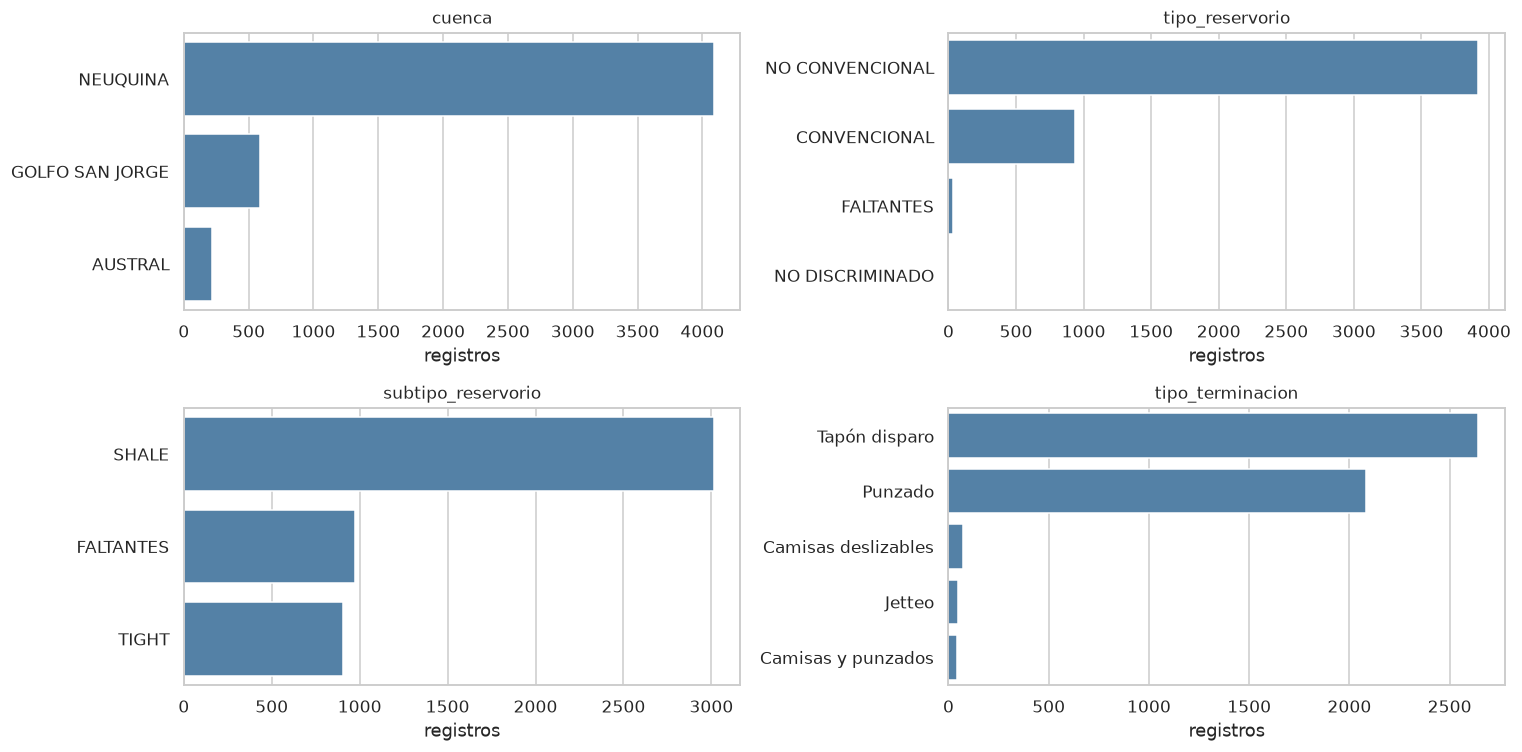

In [11]:
# Las de pocas categorías se grafican enteras
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for ax, col in zip(axes.ravel(), ["cuenca", "tipo_reservorio", "subtipo_reservorio",
                                  "tipo_terminacion"]):
    serie = df[col].fillna("FALTANTES")
    sns.countplot(y=serie, order=serie.value_counts().index, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("registros")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

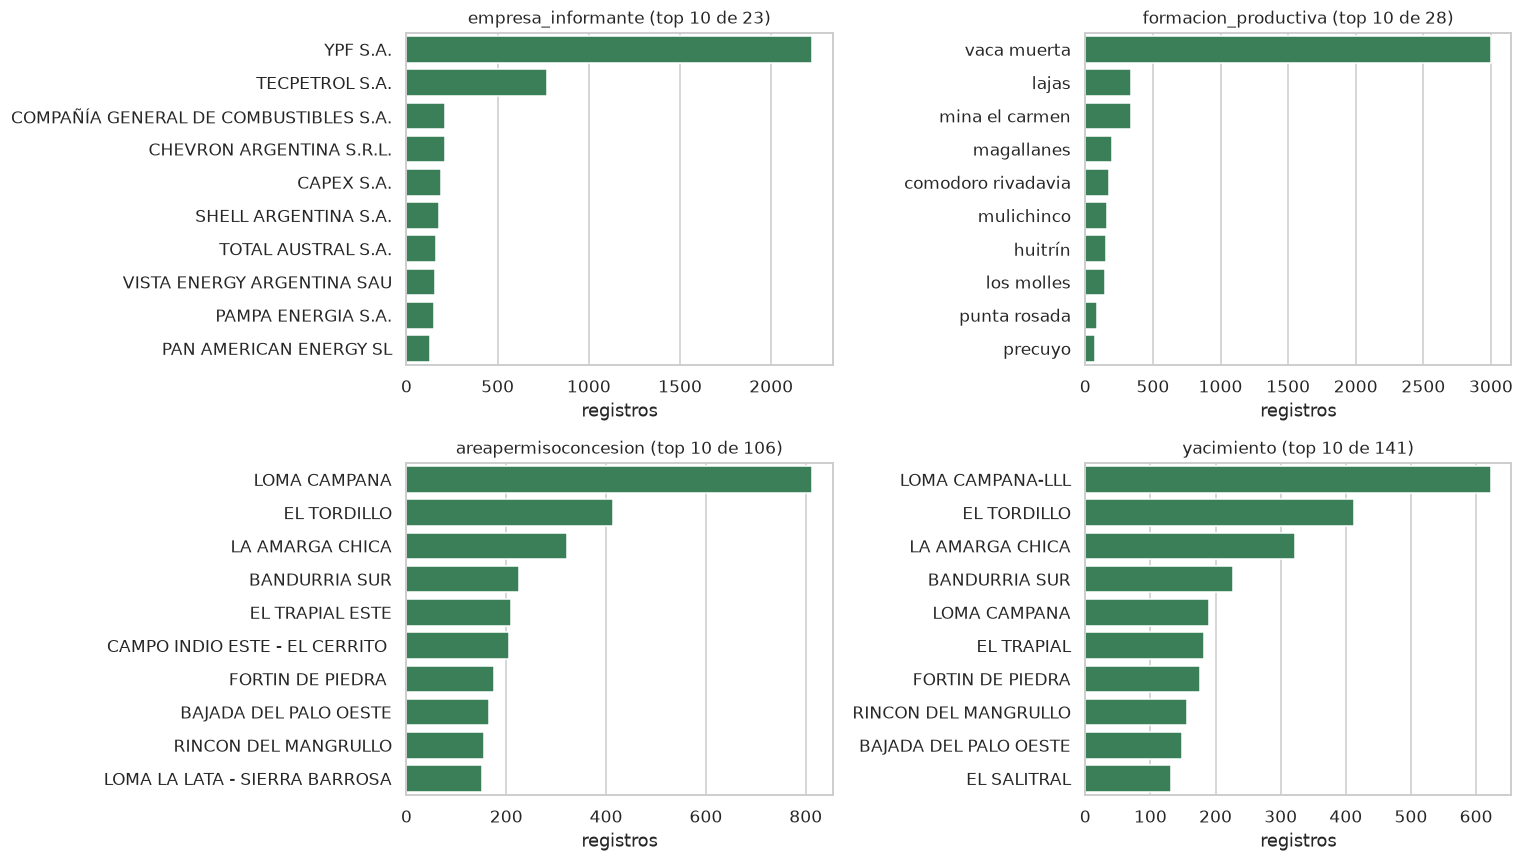

In [12]:
# Las de muchas categorías: solo el top 10, si no no se leen
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.ravel(), ["empresa_informante", "formacion_productiva",
                                  "areapermisoconcesion", "yacimiento"]):
    top = df[col].value_counts().head(10)
    sns.countplot(y=df[col], order=top.index, ax=ax, color="seagreen")
    ax.set_title(f"{col} (top 10 de {df[col].nunique()})", fontsize=11)
    ax.set_xlabel("registros")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

La actividad está **muy concentrada**. La Cuenca Neuquina reúne 4.087 de los 4.890 registros, Vaca
Muerta es la formación más frecuente con 3.001, y solo dos empresas —YPF y Tecpetrol— explican casi
el 60% de las operaciones.

`subtipo_reservorio` es la única categórica con un volumen de faltantes que se nota: casi el 20%.

# 6. Un mismo dato escrito de diferentes maneras

Una misma categoría puede aparecer varias veces escrita distinto —con espacios de más, en mayúscula
y en minúscula— y eso la partiría en dos grupos al contar. Se audita comparando cuántas categorías
hay antes y después de normalizar el texto.

In [13]:
print("Auditoría de formato en variables categóricas\n")
problemas = 0

for col in CATEGORICAS + TEXTO:
    originales = df[col].nunique()
    normalizados = df[col].str.strip().str.upper().nunique()
    if originales != normalizados:
        print(f"  {col}: {originales} categorías -> {normalizados} al normalizar "
              f"({originales - normalizados} son la misma escrita distinto)")
        problemas += 1

if problemas == 0:
    print("  Ninguna columna cambia al normalizar: la carga es consistente.")

Auditoría de formato en variables categóricas

  Ninguna columna cambia al normalizar: la carga es consistente.


El dataset está limpio en este aspecto. Igual normalizamos el texto en la Parte 2, porque es barato
y evita que una carga futura con otro formato rompa los conteos.

# 7. Análisis de la distribución de variables numéricas

Media, mediana, mínimo, máximo y forma de cada distribución.

In [14]:
df[NUMERICAS].describe().T[["mean", "50%", "min", "max"]].round(2)

,mean,50%,min,max
longitud_rama_horizontal_m,"1,338.15","1,251.50",0.00,"5,114.11"
cantidad_fracturas,23.07,17.00,1.00,105.00
arena_bombeada_nacional_tn,"4,732.52","1,974.27",0.00,"20,834.00"
arena_bombeada_importada_tn,346.18,9.10,0.00,"80,652.00"
agua_inyectada_m3,"32,444.03","18,722.47",0.00,"537,184.60"
co2_inyectado_m3,5.47,0.00,0.00,560.00
presion_maxima_psi,"9,270.16","10,932.60",0.00,"209,640.56"
potencia_equipos_fractura_hp,"20,760.55","22,033.00",0.00,"232,159.29"


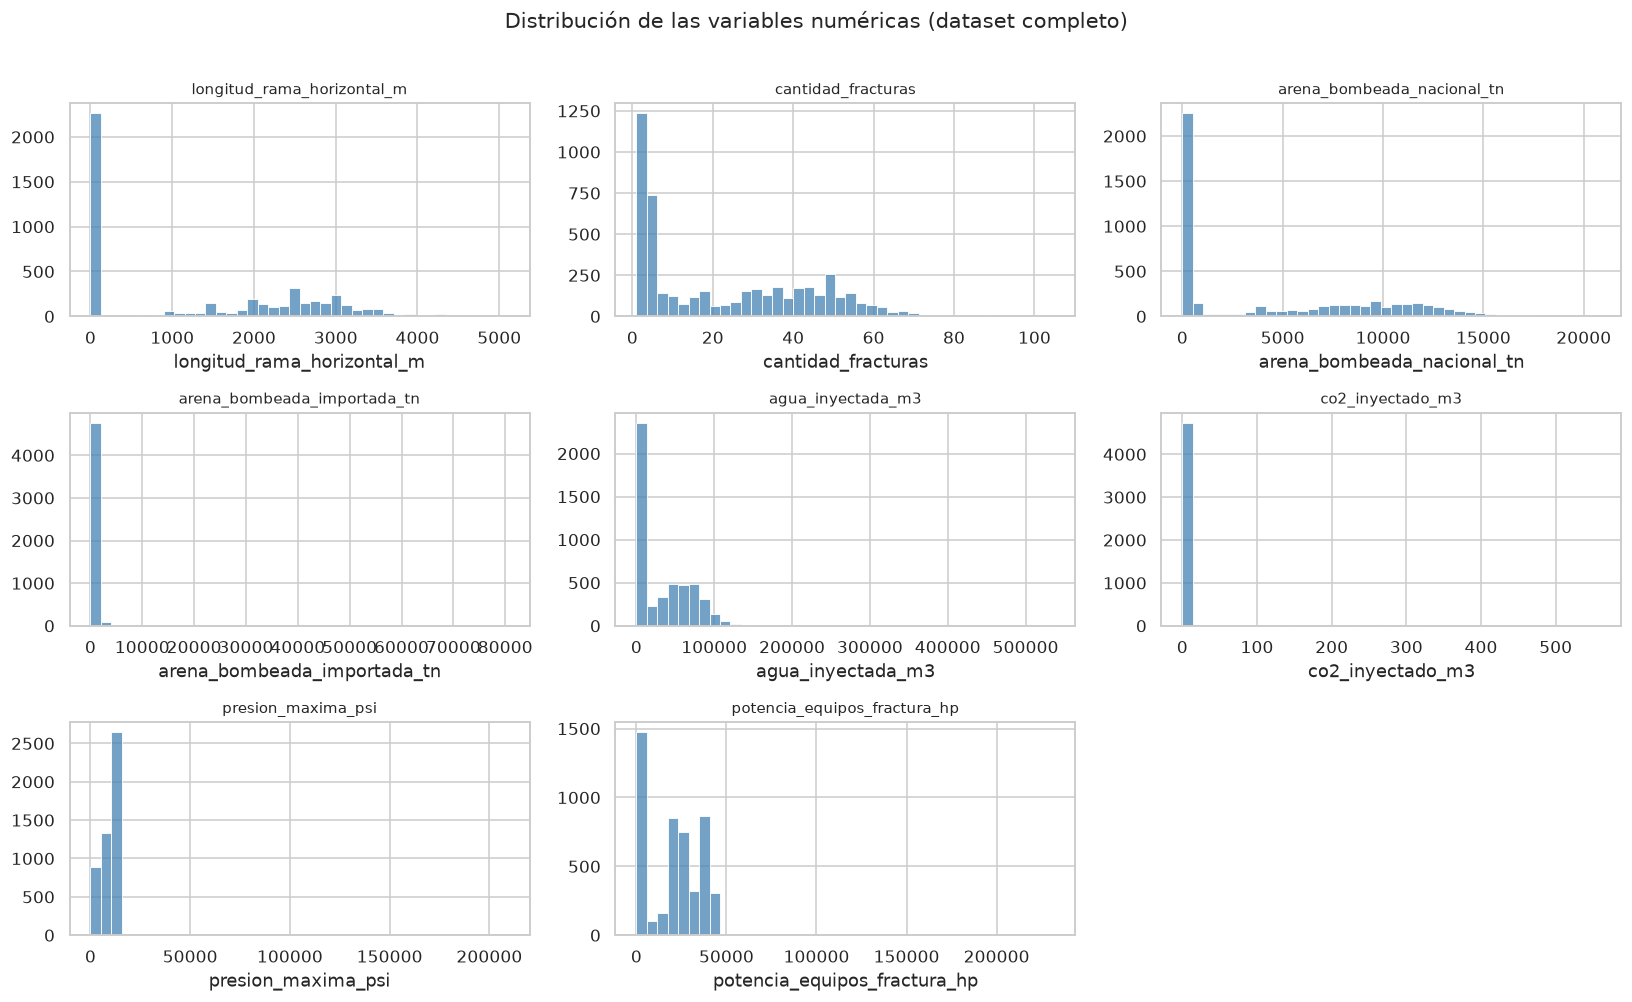

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

for ax, col in zip(axes.ravel(), NUMERICAS):
    sns.histplot(data=df, x=col, bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")

axes.ravel()[-1].axis("off")
fig.suptitle("Distribución de las variables numéricas (dataset completo)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Las distribuciones son muy asimétricas y casi todas tienen un pico pegado al cero. La de
`longitud_rama_horizontal_m` es la más llamativa: una barra enorme en cero y después una campana
lejos de ahí. Eso no es una distribución con outliers, **son dos poblaciones distintas mezcladas**.

In [16]:
# Separamos por tipo de pozo y comparamos
df["tipo_pozo"] = np.where(df["longitud_rama_horizontal_m"] > 0, "horizontal", "vertical")

print(df["tipo_pozo"].value_counts().to_string())
print()
print((df["tipo_pozo"].value_counts(normalize=True) * 100).round(1).to_string())
print()
df.groupby("tipo_pozo")[["cantidad_fracturas", "arena_bombeada_nacional_tn",
                         "agua_inyectada_m3", "presion_maxima_psi"]].median().round(1)

tipo_pozo
horizontal    2836
vertical      2054

tipo_pozo
horizontal   58.00
vertical     42.00



,cantidad_fracturas,arena_bombeada_nacional_tn,agua_inyectada_m3,presion_maxima_psi
tipo_pozo,,,,
horizontal,38.00,"8,576.10","54,313.60","11,610.00"
vertical,3.00,0.00,429.80,"6,918.00"


In [17]:
# ¿Se corresponde con el tipo de reservorio declarado?
pd.crosstab(df["tipo_reservorio"], df["tipo_pozo"], dropna=False)

tipo_pozo,horizontal,vertical
tipo_reservorio,,
CONVENCIONAL,72,861
NO CONVENCIONAL,2744,1177
NO DISCRIMINADO,1,0
NaN,19,16


> **Hallazgo — el dataset mezcla dos poblaciones incomparables.**
>
> El 42% de los registros son **pozos verticales**: un vertical mediano bombea **0 toneladas de
> arena** y 430 m³ de agua en 3 etapas; uno horizontal, 8.576 toneladas y 54.314 m³ en 38 etapas. Es
> una diferencia de escala de dos órdenes de magnitud.
>
> El cruce con `tipo_reservorio` lo confirma: los verticales son mayoritariamente convencionales y
> los horizontales, no convencionales. Son dos tecnologías distintas conviviendo en la misma tabla.
>
> Como el proyecto estudia el diseño de fractura de pozos no convencionales, en la Parte 2 vamos a
> quedarnos solo con los horizontales. Promediar las dos poblaciones no describiría a ninguna.

# 8. Detección de valores atípicos

Un valor atípico no siempre es un error. La pregunta no es "¿lo elimino?", sino **"¿es posible y
tiene sentido dentro del problema?"**.

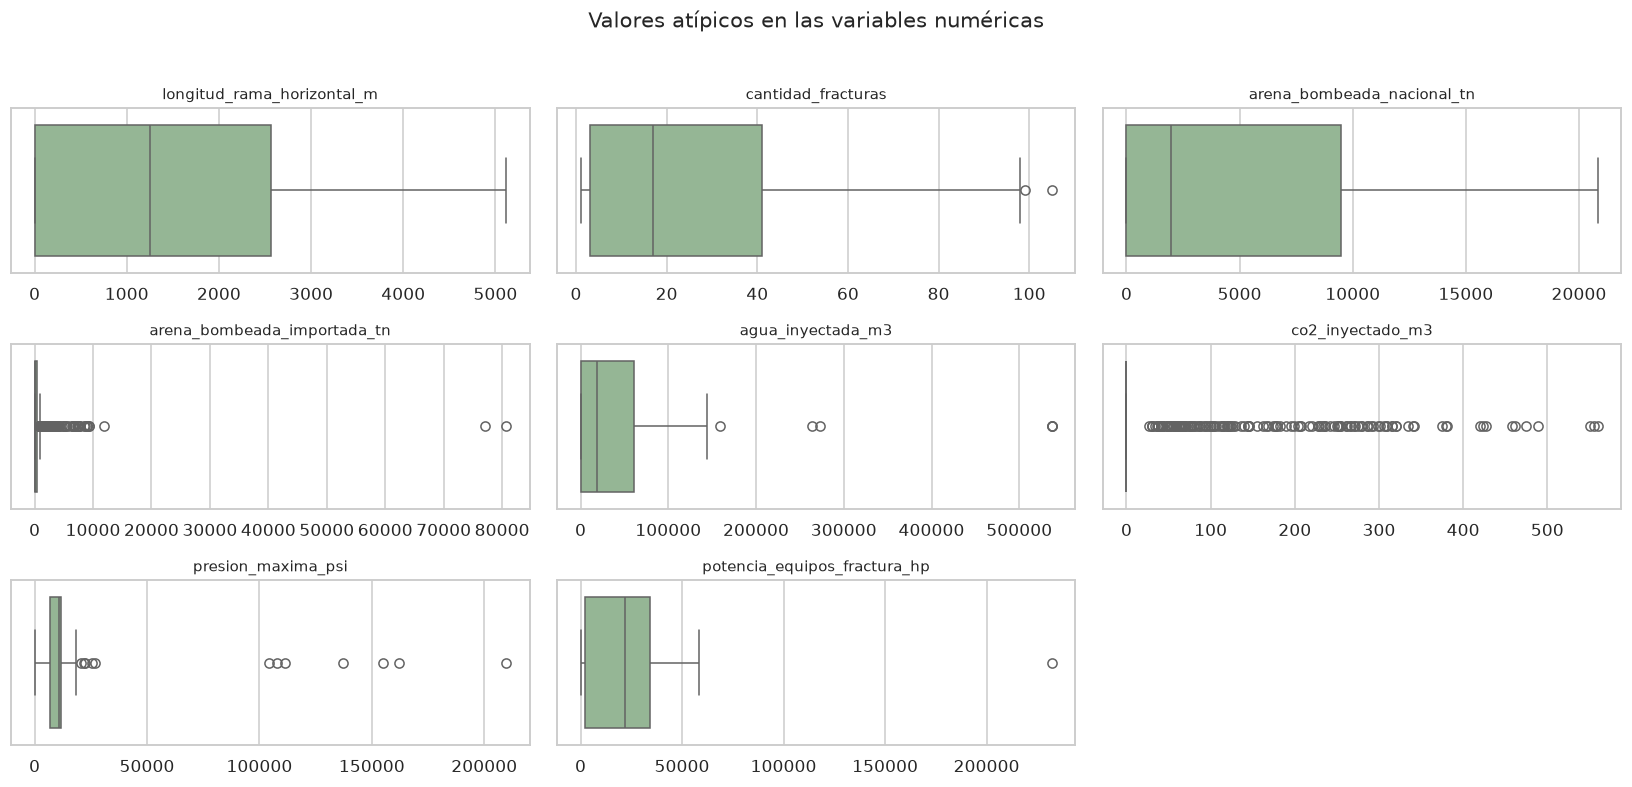

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 7))

for ax, col in zip(axes.ravel(), NUMERICAS):
    sns.boxplot(data=df, x=col, ax=ax, color="darkseagreen")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

axes.ravel()[-1].axis("off")
fig.suptitle("Valores atípicos en las variables numéricas", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Los máximos, para juzgar si son posibles
pd.DataFrame({
    "máximo": df[NUMERICAS].max().round(1),
    "mediana": df[NUMERICAS].median().round(1),
    "veces la mediana": (df[NUMERICAS].max() / df[NUMERICAS].median().replace(0, np.nan)).round(1),
})

,máximo,mediana,veces la mediana
longitud_rama_horizontal_m,"5,114.10","1,251.50",4.10
cantidad_fracturas,105.00,17.00,6.20
arena_bombeada_nacional_tn,"20,834.00","1,974.30",10.60
arena_bombeada_importada_tn,"80,652.00",9.10,"8,862.90"
agua_inyectada_m3,"537,184.60","18,722.50",28.70
co2_inyectado_m3,560.00,0.00,NaN
presion_maxima_psi,"209,640.60","10,932.60",19.20
potencia_equipos_fractura_hp,"232,159.30","22,033.00",10.50


Dos valores no resisten el contraste con la realidad de la operación:

- **`presion_maxima_psi` llega a 209.640.** Una fractura real trabaja entre 5.000 y 15.000 psi.
- **`potencia_equipos_fractura_hp` llega a 232.159.** Un equipo completo de fractura ronda los
  40.000 hp.

Ambos exceden por más de un orden de magnitud lo que un equipo puede hacer: no son pozos
excepcionales, son **errores de carga**.

# 9. Comportamiento de los valores atípicos

Dos casos merecen mirarse de cerca, porque cambian decisiones posteriores.

## 9.1 La cola baja de la longitud de rama

In [20]:
cola_baja = df.loc[df["longitud_rama_horizontal_m"].between(0.1, 800),
                   "longitud_rama_horizontal_m"]

print(f"Pozos con rama entre 0 y 800 m: {len(cola_baja)}")
print()
print("Valores más frecuentes en esa cola:")
print(cola_baja.value_counts().head(8).to_string())

Pozos con rama entre 0 y 800 m: 248

Valores más frecuentes en esa cola:
longitud_rama_horizontal_m
3.00     63
5.00      6
4.00      5
0.80      4
8.00      4
6.00      4
11.00     4
65.00     3


> **Hallazgo — hay un valor de relleno en la longitud de rama.**
>
> El número **3,0 se repite 63 veces**. Un pozo horizontal de tres metros no existe: si algo mide
> tres metros, no es un pozo. Es lo que alguien cargó cuando no tenía el dato real, igual que los
> valores de 0,8 y 11 metros.
>
> El problema no es que sobren 63 filas. Es que en la Parte 3 vamos a **dividir la arena por la
> longitud** para medir la intensidad del diseño, y dividir por 3 da un número absurdo que arruina
> la comparación entre pozos.

## 9.2 El CO2

`co2_inyectado_m3` vale cero en el 96,7% de los registros. Eso invita a descartarla por constante,
pero antes conviene mirar el 3,3% restante.

In [21]:
con_co2 = df[df["co2_inyectado_m3"] > 0]

print(f"Registros con CO2 > 0: {len(con_co2)}")
print(con_co2["tipo_pozo"].value_counts().to_string())
print(f"\nAños en que se usó: {con_co2['anio_if'].min()} a {con_co2['anio_if'].max()}")

Registros con CO2 > 0: 159
tipo_pozo
vertical    159

Años en que se usó: 2010 a 2022


> **Hallazgo — el CO2 se usó solo en pozos verticales.**
>
> Los 159 registros con CO2 son **todos verticales**, entre 2010 y 2022. Dentro de la población que
> vamos a analizar, la columna es idénticamente cero y no aporta nada.
>
> Es un buen ejemplo de por qué conviene mirar antes de descartar: si nos hubiéramos guiado solo por
> el porcentaje de ceros global, la conclusión habría sido otra.

# 10. Relación entre variables

Observar una tendencia no demuestra causalidad, pero sugiere relaciones para investigar.

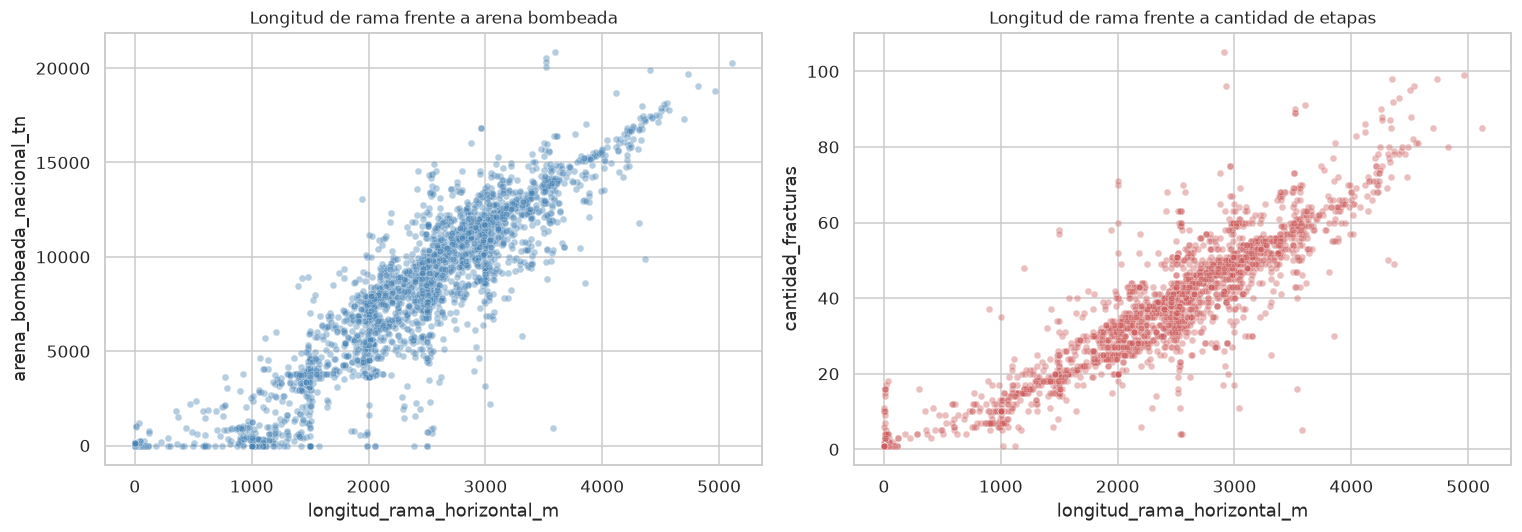

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df[df["tipo_pozo"] == "horizontal"],
                x="longitud_rama_horizontal_m", y="arena_bombeada_nacional_tn",
                alpha=0.4, s=20, ax=axes[0], color="steelblue")
axes[0].set_title("Longitud de rama frente a arena bombeada", fontsize=11)

sns.scatterplot(data=df[df["tipo_pozo"] == "horizontal"],
                x="longitud_rama_horizontal_m", y="cantidad_fracturas",
                alpha=0.4, s=20, ax=axes[1], color="indianred")
axes[1].set_title("Longitud de rama frente a cantidad de etapas", fontsize=11)

plt.tight_layout()
plt.show()

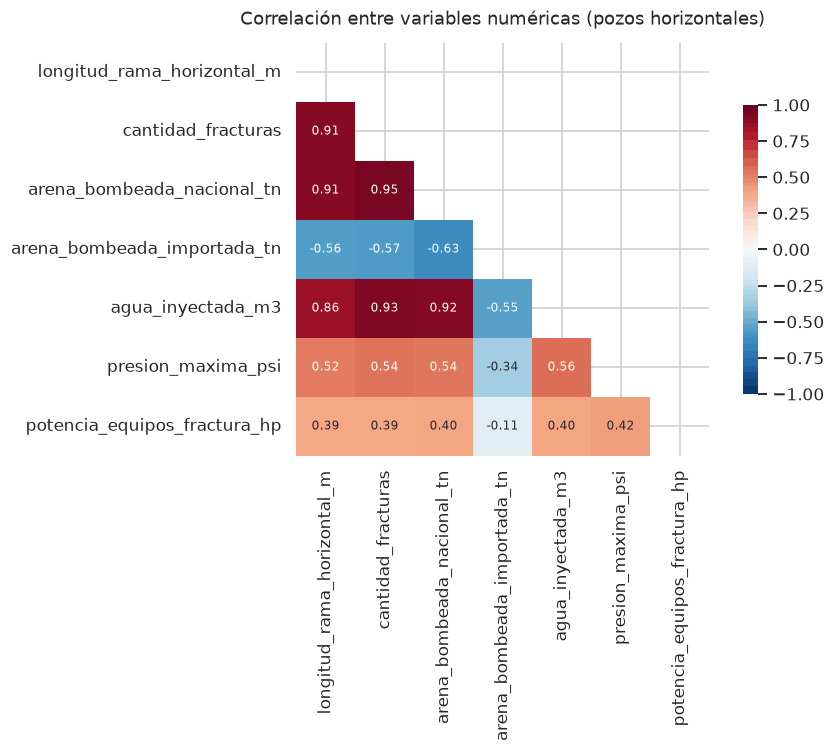

In [23]:
# Correlación de Spearman, que capta relaciones monótonas aunque no sean lineales
horiz = df[df["tipo_pozo"] == "horizontal"]
matriz = horiz[NUMERICAS].drop(columns="co2_inyectado_m3").corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
mascara = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlación entre variables numéricas (pozos horizontales)", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

> **Hallazgo — las variables de diseño están muy correlacionadas entre sí.**
>
> La longitud de rama correlaciona **0,91 con la arena** y **0,91 con las etapas**. Tiene sentido
> físico: un pozo más largo lleva más etapas y cada etapa consume arena.
>
> Es información importante para la etapa de modelado: usar las tres juntas como variables
> independientes daría resultados inestables, porque en el fondo están midiendo lo mismo. Hay que
> quedarse con una variable de tamaño y construir variables de **intensidad** que sean
> independientes de él. Eso es lo que hacemos en la Parte 3.

# 11. Comparando grupos

¿Qué grupo tiene mayor mediana? ¿Cuál presenta más dispersión? ¿Los tamaños son parecidos?

In [24]:
# Las seis operadoras con más pozos horizontales
top_empresas = horiz["empresa_informante"].value_counts().head(6).index
subset = horiz[horiz["empresa_informante"].isin(top_empresas)]

(subset.groupby("empresa_informante")
       .agg(pozos=("idpozo", "size"),
            rama_mediana=("longitud_rama_horizontal_m", "median"),
            etapas_medianas=("cantidad_fracturas", "median"),
            arena_mediana=("arena_bombeada_nacional_tn", "median"))
       .sort_values("rama_mediana", ascending=False)
       .round(1))

,pozos,rama_mediana,etapas_medianas,arena_mediana
empresa_informante,,,,
VISTA ENERGY ARGENTINA SAU,159,"2,901.00",49.00,"12,053.10"
PAN AMERICAN ENERGY SL,121,"2,556.00",42.00,"8,480.90"
SHELL ARGENTINA S.A.,180,"2,550.00",35.00,"8,330.30"
TECPETROL S.A.,169,"2,516.00",39.00,"7,812.20"
YPF S.A.,1394,"2,483.50",38.00,"8,785.10"
TOTAL AUSTRAL S.A.,157,"1,960.00",20.00,"4,182.00"


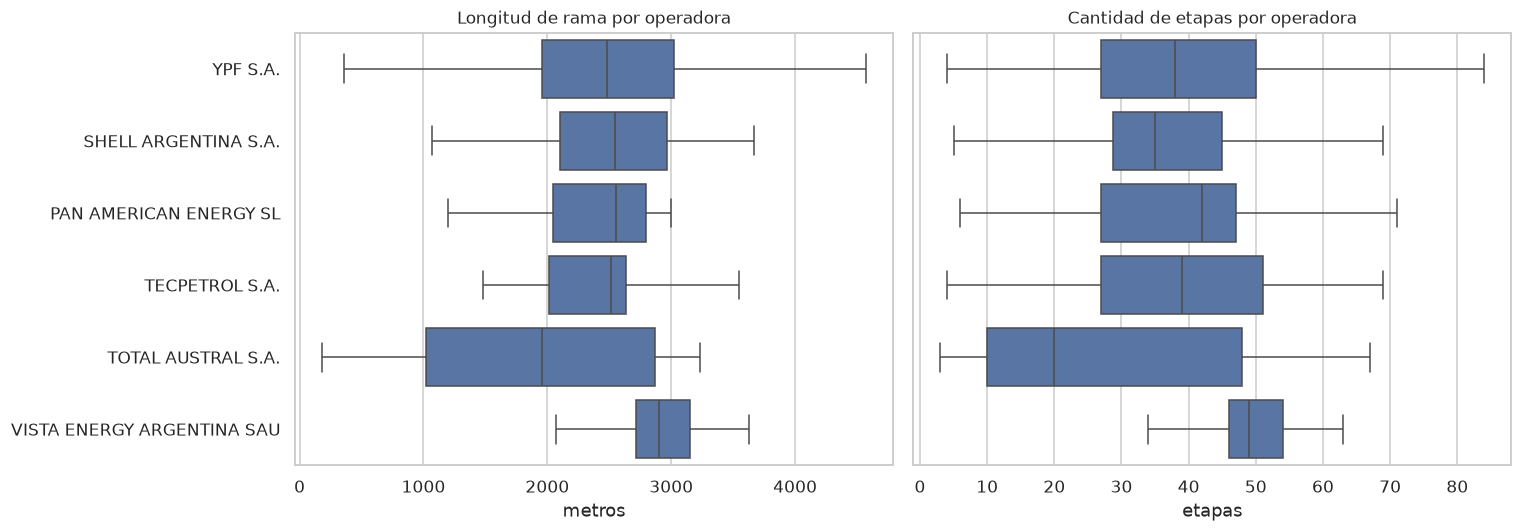

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=subset, y="empresa_informante", x="longitud_rama_horizontal_m",
            ax=axes[0], showfliers=False)
axes[0].set_title("Longitud de rama por operadora", fontsize=11)
axes[0].set_xlabel("metros")
axes[0].set_ylabel("")

sns.boxplot(data=subset, y="empresa_informante", x="cantidad_fracturas",
            ax=axes[1], showfliers=False)
axes[1].set_title("Cantidad de etapas por operadora", fontsize=11)
axes[1].set_xlabel("etapas")
axes[1].set_ylabel("")
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

Las operadoras no diseñan igual, y la diferencia no está solo en la mediana: **también en la
dispersión**. Algunas muestran cajas angostas —repiten una receta estandarizada en todos sus
pozos— y otras cajas anchas, señal de que deciden pozo por pozo.

Los tamaños de grupo son muy desparejos: YPF sola tiene más pozos que las otras cinco juntas, así
que cualquier promedio general va a estar dominado por su forma de trabajar.

# 12. Análisis de posible variable objetivo

El objetivo final del proyecto es **predecir cuánto produce un pozo a partir de su diseño**. Esa
variable —la producción acumulada— no está en esta tabla: vive en el dataset de *Producción de
petróleo y gas por pozo* de la misma Secretaría, que se vincula con este por `idpozo`.

Se incorporará en la etapa de modelado. En esta entrega dejamos identificado qué variable será y
qué relación esperamos: que los pozos con mayor intensidad de fractura produzcan más, y que esa
mejora tenga un techo.

Mientras tanto, la variable que más se le parece dentro de esta tabla es la **intensidad de
completación** —arena por metro de rama—, que construimos en la Parte 3 y que resume en un solo
número cuán agresivo es el diseño.

# Parte 2: Transformación y limpieza de datos

Hasta acá solo miramos. Ahora corregimos lo que el análisis detectó, en este orden:

| Punto | Paso |
|---|---|
| 13 | Conversión de fechas |
| 14 | Normalización de categorías |
| 15 | Tratamiento de valores faltantes |
| 16 | Validación de errores y definición del alcance |
| 17 | Eliminación de duplicados: consolidación de cargas parciales |

Trabajamos sobre una copia: **el dataset original no se modifica nunca**.

In [26]:
df_copia = df.copy()
print(f"Copia de trabajo: {df_copia.shape}")

Copia de trabajo: (4890, 31)


# 13. Conversión de fechas

En el `info()` vimos que las fechas están como texto. Sin convertirlas no se puede calcular una
duración ni ordenar cronológicamente.

In [27]:
for col in ["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data"]:
    df_copia[col] = pd.to_datetime(df_copia[col], errors="coerce")

print(df_copia[["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data"]].dtypes.to_string())
print()
print(f"Rango de fechas de fractura: {df_copia['fecha_inicio_fractura'].min():%Y-%m-%d} "
      f"a {df_copia['fecha_inicio_fractura'].max():%Y-%m-%d}")

fecha_inicio_fractura    datetime64[us]
fecha_fin_fractura       datetime64[us]
fecha_data               datetime64[us]

Rango de fechas de fractura: 2006-05-19 a 2026-12-05


# 14. Normalización de categorías

Quitamos espacios sobrantes y unificamos a minúsculas. La auditoría del punto 6 dio limpia, así que
esto es preventivo: evita que una carga futura con otro formato parta una categoría en dos.

In [28]:
for col in CATEGORICAS:
    df_copia[col] = df_copia[col].astype(str).str.strip().str.lower()
    df_copia[col] = df_copia[col].replace({"nan": np.nan, "": np.nan})

df_copia[CATEGORICAS].nunique().to_frame("categorías tras normalizar")

,categorías tras normalizar
cuenca,3
areapermisoconcesion,106
yacimiento,141
formacion_productiva,28
tipo_reservorio,3
subtipo_reservorio,2
tipo_terminacion,5
empresa_informante,23


# 15. Tratamiento de valores faltantes

Imputar no es adivinar sin consecuencias: modifica los datos y hay que justificarlo. Lo decidimos
variable por variable.

| Variable | Faltantes | Decisión |
|---|---|---|
| `subtipo_reservorio` | 974 | Etiqueta **"sin dato"**: es una categoría real y desconocida, no queremos inventarle un valor |
| `tipo_reservorio` | 35 | Etiqueta **"sin dato"**, por la misma razón |
| `potencia_equipos_fractura_hp` | 51 | Se trata junto con los ceros en el punto 16, porque son el mismo problema |

Para las categóricas elegimos etiqueta y no la moda: decir que un pozo es "shale" solo porque es lo
más común sería inventar información que no tenemos.

In [29]:
for col in ["subtipo_reservorio", "tipo_reservorio"]:
    antes = df_copia[col].isnull().sum()
    df_copia[col] = df_copia[col].fillna("sin dato")
    print(f"{col}: {antes} faltantes etiquetados como 'sin dato'")

print()
print("Faltantes restantes en categóricas:", int(df_copia[CATEGORICAS].isnull().sum().sum()))

subtipo_reservorio: 974 faltantes etiquetados como 'sin dato'
tipo_reservorio: 35 faltantes etiquetados como 'sin dato'

Faltantes restantes en categóricas: 0


# 16. Validación de errores y definición del alcance

Los valores pueden estar presentes y ser igualmente erróneos. Para identificarlos hay que aplicar
reglas del contexto.

**Estas reglas no salen del dataset ni de ninguna documentación: las deducimos de la física de la
operación y de la lógica del calendario.** Son de tres tipos:

- **Coherencia temporal.** Una fractura no puede terminar antes de empezar, ni ejecutarse en una
  fecha futura.
- **Signo.** Ninguna magnitud física de esta tabla puede ser negativa.
- **Cero imposible.** Un equipo de fractura no opera a cero psi, no tiene cero caballos de fuerza y
  no bombea cero metros cúbicos de fluido. Ahí el cero no es una medición: es un dato que no se
  cargó.

In [30]:
reglas = {
    "Fecha de fin anterior a la de inicio":
        (df_copia["fecha_fin_fractura"] < df_copia["fecha_inicio_fractura"]).sum(),
    "Fecha de fractura posterior a hoy":
        (df_copia["fecha_inicio_fractura"] > HOY).sum(),
    "Presión máxima igual a cero":
        (df_copia["presion_maxima_psi"] == 0).sum(),
    "Potencia de equipos igual a cero o nula":
        ((df_copia["potencia_equipos_fractura_hp"] == 0)
         | df_copia["potencia_equipos_fractura_hp"].isnull()).sum(),
    "Agua inyectada igual a cero":
        (df_copia["agua_inyectada_m3"] == 0).sum(),
    "Valores negativos en variables físicas":
        int((df_copia[NUMERICAS] < 0).sum().sum()),
}
pd.Series(reglas, name="registros").to_frame()

,registros
Fecha de fin anterior a la de inicio,41
Fecha de fractura posterior a hoy,3
Presión máxima igual a cero,78
Potencia de equipos igual a cero o nula,205
Agua inyectada igual a cero,305
Valores negativos en variables físicas,0


In [31]:
# Las fechas imposibles pasan a nulo: sabemos que están mal, no cuál era la correcta
df_copia.loc[df_copia["fecha_fin_fractura"] < df_copia["fecha_inicio_fractura"],
             "fecha_fin_fractura"] = pd.NaT
df_copia.loc[df_copia["fecha_inicio_fractura"] > HOY, "fecha_inicio_fractura"] = pd.NaT

print("Fechas imposibles convertidas a nulo.")
print(f"Nulos ahora en fecha_fin_fractura:    {df_copia['fecha_fin_fractura'].isnull().sum()}")
print(f"Nulos ahora en fecha_inicio_fractura: {df_copia['fecha_inicio_fractura'].isnull().sum()}")

Fechas imposibles convertidas a nulo.
Nulos ahora en fecha_fin_fractura:    41
Nulos ahora en fecha_inicio_fractura: 3


## 16.1 Definición del alcance

En el punto 7 vimos que el dataset mezcla pozos verticales y horizontales, y que son tecnologías de
escala distinta. Como el proyecto estudia el diseño de fractura de pozos no convencionales, nos
quedamos con los **horizontales**.

Pero en el punto 9 vimos que hay longitudes de relleno, así que "mayor a cero" no alcanza como
criterio. Hay que elegir un largo mínimo, y en lugar de elegirlo a ojo probamos varios mirando dos
cosas:

- **Cuántos pozos perdemos.** Un umbral que tire media tabla no sirve, por prolijo que sea.
- **Si el espaciamiento entre etapas se estabiliza.** Este es el termómetro: separar las etapas es
  una decisión de ingeniería que en la práctica se mueve en un rango angosto. Cuando al subir el
  umbral el espaciamiento típico deja de moverse, es señal de que nos quedamos solo con los pozos
  cuya longitud es confiable.

In [32]:
horizontales = df_copia[df_copia["longitud_rama_horizontal_m"] > 0]

for umbral in [0, 100, 300, 500, 800, 1000]:
    sub = horizontales[horizontales["longitud_rama_horizontal_m"] >= umbral]
    espaciamiento = (sub["longitud_rama_horizontal_m"] / sub["cantidad_fracturas"]).median()
    intensidad_max = (sub["arena_bombeada_nacional_tn"]
                      / sub["longitud_rama_horizontal_m"]).max()
    print(f"rama >= {umbral:5d} m  ->  {len(sub):5,} registros "
          f"({100 * len(sub) / len(horizontales):5.1f}%)"
          f"  |  espaciamiento mediano {espaciamiento:5.1f} m"
          f"  |  arena por metro máxima {intensidad_max:8.1f} tn")

rama >=     0 m  ->  2,836 registros (100.0%)  |  espaciamiento mediano  62.3 m  |  arena por metro máxima    102.4 tn
rama >=   100 m  ->  2,634 registros ( 92.9%)  |  espaciamiento mediano  63.3 m  |  arena por metro máxima      6.7 tn
rama >=   300 m  ->  2,625 registros ( 92.6%)  |  espaciamiento mediano  63.3 m  |  arena por metro máxima      6.7 tn
rama >=   500 m  ->  2,616 registros ( 92.2%)  |  espaciamiento mediano  63.3 m  |  arena por metro máxima      6.7 tn
rama >=   800 m  ->  2,589 registros ( 91.3%)  |  espaciamiento mediano  63.1 m  |  arena por metro máxima      6.7 tn
rama >=  1000 m  ->  2,544 registros ( 89.7%)  |  espaciamiento mediano  62.8 m  |  arena por metro máxima      6.7 tn


Sin filtro aparece una intensidad máxima de **102 toneladas de arena por metro**, unas 25 veces el
valor típico: es el efecto de dividir arena real por una rama de 3 metros. A partir de los 100 m el
espaciamiento se estabiliza en 63 m y la intensidad máxima se vuelve razonable.

**Elegimos 500 m**, porque conserva casi los mismos pozos que 100 m —92,2% contra 92,9%— y descarta
con más margen la zona donde la longitud reportada no es confiable.

In [33]:
UMBRAL_RAMA_M = 500

antes = len(df_copia)
df_copia = df_copia[df_copia["longitud_rama_horizontal_m"] >= UMBRAL_RAMA_M].copy()

print(f"Registros antes del filtro:   {antes:,}")
print(f"Registros después del filtro: {len(df_copia):,}")
print(f"Descartados:                  {antes - len(df_copia):,}")

Registros antes del filtro:   4,890
Registros después del filtro: 2,616
Descartados:                  2,274


# 17. Eliminación de duplicados: consolidación de cargas parciales

En el punto 4 vimos que los registros repetidos son cargas parciales de una misma operación. No se
eliminan: **se suman**, para reconstruir la operación completa.

El criterio es distinto según qué mide cada columna:

- **Magnitudes que se acumulan** (etapas, arena, agua): se **suman**, porque cada carga aporta su
  parte.
- **Propiedades del pozo** (longitud de rama, presión máxima, potencia): se toma el **máximo**,
  porque la rama no se hace más larga por cargarla en dos filas.
- **Ventana temporal**: la fecha de inicio más temprana y la de fin más tardía.
- **Atributos constantes** (operadora, formación, cuenca): el primero, porque no cambian.

In [34]:
AGREGACIONES = {
    "longitud_rama_horizontal_m": "max",
    "presion_maxima_psi": "max",
    "potencia_equipos_fractura_hp": "max",
    "cantidad_fracturas": "sum",
    "arena_bombeada_nacional_tn": "sum",
    "arena_bombeada_importada_tn": "sum",
    "agua_inyectada_m3": "sum",
    "fecha_inicio_fractura": "min",
    "fecha_fin_fractura": "max",
    "sigla": "first",
    "cuenca": "first",
    "areapermisoconcesion": "first",
    "yacimiento": "first",
    "formacion_productiva": "first",
    "tipo_reservorio": "first",
    "subtipo_reservorio": "first",
    "tipo_terminacion": "first",
    "empresa_informante": "first",
}

antes = len(df_copia)
df_copia = (df_copia.groupby("idpozo")
                    .agg(**{col: (col, func) for col, func in AGREGACIONES.items()})
                    .reset_index())

print(f"Registros antes de consolidar: {antes:,}")
print(f"Pozos después de consolidar:   {len(df_copia):,}")

Registros antes de consolidar: 2,616
Pozos después de consolidar:   2,603


## 17.1 Corrección de los ceros y los valores extremos

Ahora que cada fila es un pozo completo, corregimos los ceros imposibles y los valores extremos que
detectamos en los puntos 8 y 16. Se hace **después** de consolidar a propósito: si imputáramos antes,
sumaríamos valores inventados de varias cargas parciales del mismo pozo.

**Criterio:** reemplazar por la **mediana de la formación**. Usamos la mediana y no la media porque,
como vimos en los boxplots, estas variables tienen valores atípicos que correrían el promedio.

In [35]:
# Ceros imposibles -> mediana de la formación
for col in ["presion_maxima_psi", "potencia_equipos_fractura_hp", "agua_inyectada_m3"]:
    faltantes = (df_copia[col] == 0) | df_copia[col].isnull()
    mediana_formacion = df_copia.loc[~faltantes].groupby("formacion_productiva")[col].median()

    df_copia.loc[faltantes, col] = (df_copia.loc[faltantes, "formacion_productiva"]
                                    .map(mediana_formacion))
    df_copia[col] = df_copia[col].fillna(df_copia.loc[~faltantes, col].median())

    print(f"{col}: {faltantes.sum()} ceros o nulos reemplazados por la mediana de su formación")

presion_maxima_psi: 3 ceros o nulos reemplazados por la mediana de su formación
potencia_equipos_fractura_hp: 44 ceros o nulos reemplazados por la mediana de su formación
agua_inyectada_m3: 3 ceros o nulos reemplazados por la mediana de su formación


In [36]:
# Valores extremos -> misma lógica
for col in ["presion_maxima_psi", "potencia_equipos_fractura_hp"]:
    inferior, superior = df_copia[col].quantile([0.01, 0.99])
    extremos = (df_copia[col] < inferior) | (df_copia[col] > superior)

    mediana_formacion = df_copia.loc[~extremos].groupby("formacion_productiva")[col].median()
    df_copia.loc[extremos, col] = (df_copia.loc[extremos, "formacion_productiva"]
                                   .map(mediana_formacion))
    df_copia[col] = df_copia[col].fillna(df_copia.loc[~extremos, col].median())

    print(f"{col}: {extremos.sum()} valores fuera de "
          f"[{inferior:,.0f} , {superior:,.0f}] reemplazados por la mediana")

print()
print(f"Nulos restantes en variables numéricas: "
      f"{int(df_copia.select_dtypes('number').isnull().sum().sum())}")

presion_maxima_psi: 54 valores fuera de [6,600 , 13,846] reemplazados por la mediana
potencia_equipos_fractura_hp: 26 valores fuera de [2,000 , 44,000] reemplazados por la mediana

Nulos restantes en variables numéricas: 0


In [37]:
# co2_inyectado_m3 ya no está: era idénticamente cero en esta población.
# Verificamos que efectivamente no quedó nada que aporte información.
constantes = [c for c in df_copia.columns if df_copia[c].nunique() <= 1]
print("Columnas constantes tras la limpieza:", constantes if constantes else "ninguna")
print()
print(f"Dataset limpio: {df_copia.shape[0]:,} pozos x {df_copia.shape[1]} columnas")

Columnas constantes tras la limpieza: ninguna

Dataset limpio: 2,603 pozos x 19 columnas


# Parte 3: Introducción a Feature Engineering

# 18. Creación de variables

Las variables crudas no son comparables entre pozos: uno con más arena puede simplemente ser más
largo. En el punto 10 vimos que longitud, etapas y arena correlacionan 0,91 entre sí, justamente por
eso.

Las variables derivadas resuelven ese problema: normalizan por escala y capturan la **intensidad**
del diseño, que es lo que la industria efectivamente discute cuando compara pozos.

In [38]:
d = df_copia

# Intensidad: cuánto se bombea por unidad de pozo
d["arena_total_tn"] = d["arena_bombeada_nacional_tn"] + d["arena_bombeada_importada_tn"]
d["arena_por_metro"] = d["arena_total_tn"] / d["longitud_rama_horizontal_m"]
d["agua_por_metro"] = d["agua_inyectada_m3"] / d["longitud_rama_horizontal_m"]
d["arena_por_etapa"] = d["arena_total_tn"] / d["cantidad_fracturas"]
d["agua_por_etapa"] = d["agua_inyectada_m3"] / d["cantidad_fracturas"]

# Cuán juntas están las fracturas
d["espaciamiento_etapas_m"] = d["longitud_rama_horizontal_m"] / d["cantidad_fracturas"]

# Composición del tratamiento
d["ratio_arena_importada"] = (d["arena_bombeada_importada_tn"]
                              / d["arena_total_tn"].replace(0, np.nan)).fillna(0)
d["ratio_agua_arena"] = d["agua_inyectada_m3"] / d["arena_total_tn"].replace(0, np.nan)
d["usa_arena_importada"] = (d["arena_bombeada_importada_tn"] > 0).astype(int)

# Temporales
d["duracion_fractura_dias"] = (d["fecha_fin_fractura"] - d["fecha_inicio_fractura"]).dt.days
d["anio_fractura"] = d["fecha_inicio_fractura"].dt.year

# Bandera geológica: el 97% son de Vaca Muerta, el resto tiene otra escala
d["es_vaca_muerta"] = (d["formacion_productiva"] == "vaca muerta").astype(int)

DERIVADAS = ["arena_total_tn", "arena_por_metro", "agua_por_metro", "arena_por_etapa",
             "agua_por_etapa", "espaciamiento_etapas_m", "ratio_arena_importada",
             "ratio_agua_arena", "duracion_fractura_dias"]

d[DERIVADAS].describe().T[["mean", "50%", "min", "max"]].round(2)

,mean,50%,min,max
arena_total_tn,"9,037.99","9,173.99",123.34,"91,094.00"
arena_por_metro,3.50,3.63,0.11,38.73
agua_por_metro,22.31,22.58,0.20,163.03
arena_por_etapa,227.98,233.08,6.92,"2,602.69"
agua_por_etapa,"1,441.29","1,435.36",23.96,"10,330.47"
espaciamiento_etapas_m,69.52,63.24,24.32,"1,123.40"
ratio_arena_importada,0.07,0.00,0.00,1.00
ratio_agua_arena,6.36,6.21,0.14,29.15
duracion_fractura_dias,35.17,23.00,0.00,"1,889.00"


## 18.1 Control de plausibilidad de las nuevas variables

Las derivadas heredan los errores de las columnas de origen, así que se revisan igual que las
originales.

In [39]:
implausibles = {
    "Espaciamiento entre etapas mayor a 200 m": (d["espaciamiento_etapas_m"] > 200).sum(),
    "Pozos con 2 etapas o menos": (d["cantidad_fracturas"] <= 2).sum(),
    "Duración de la fractura mayor a un año": (d["duracion_fractura_dias"] > 365).sum(),
    "Duración nula porque falta una fecha": d["duracion_fractura_dias"].isnull().sum(),
}
pd.Series(implausibles, name="pozos").to_frame()

,pozos
Espaciamiento entre etapas mayor a 200 m,10
Pozos con 2 etapas o menos,2
Duración de la fractura mayor a un año,22
Duración nula porque falta una fecha,33


Un puñado de pozos declara una o dos etapas para más de 500 m de rama, lo que da espaciamientos de
cientos de metros que ninguna operadora usaría. Son cargas incompletas: la longitud está bien pero
las etapas no se reportaron enteras.

Son pocos casos, así que los marcamos con una bandera en lugar de eliminarlos: se pueden excluir al
modelar sin perderlos del análisis descriptivo.

In [40]:
d["carga_sospechosa"] = ((d["espaciamiento_etapas_m"] > 200)
                         | (d["cantidad_fracturas"] <= 2)).astype(int)

print(f"Pozos marcados como carga sospechosa: {d['carga_sospechosa'].sum()} "
      f"({100 * d['carga_sospechosa'].mean():.1f}%)")

Pozos marcados como carga sospechosa: 10 (0.4%)


## 18.2 ¿Qué muestran las variables nuevas?

Con la intensidad construida podemos responder la pregunta del proyecto: cómo cambió el diseño de
los pozos a lo largo del tiempo.

In [41]:
evolucion = (d.groupby("anio_fractura")
              .agg(pozos=("idpozo", "size"),
                   rama=("longitud_rama_horizontal_m", "median"),
                   etapas=("cantidad_fracturas", "median"),
                   arena=("arena_total_tn", "median"),
                   arena_por_metro=("arena_por_metro", "median"),
                   espaciamiento=("espaciamiento_etapas_m", "median")))

evolucion = evolucion[evolucion["pozos"] >= 10]
evolucion.round(1)

,pozos,rama,etapas,arena,arena_por_metro,espaciamiento
anio_fractura,,,,,,
"2,013.00",10,924.50,7.00,384.70,0.40,114.80
"2,014.00",21,"1,060.00",10.00,"2,276.80",2.30,100.00
"2,015.00",49,"1,212.00",15.00,"3,428.20",2.80,78.30
"2,016.00",115,"1,410.10",18.00,"3,882.40",2.80,78.90
"2,017.00",150,"1,579.30",20.00,"4,545.50",2.70,78.20
"2,018.00",187,"2,000.00",26.00,"6,067.90",3.00,78.40
"2,019.00",192,"2,187.20",32.00,"7,709.00",3.60,69.60
"2,020.00",80,"2,326.50",32.00,"7,450.20",3.60,65.60
"2,021.00",234,"2,538.00",37.50,"8,507.50",3.50,65.90


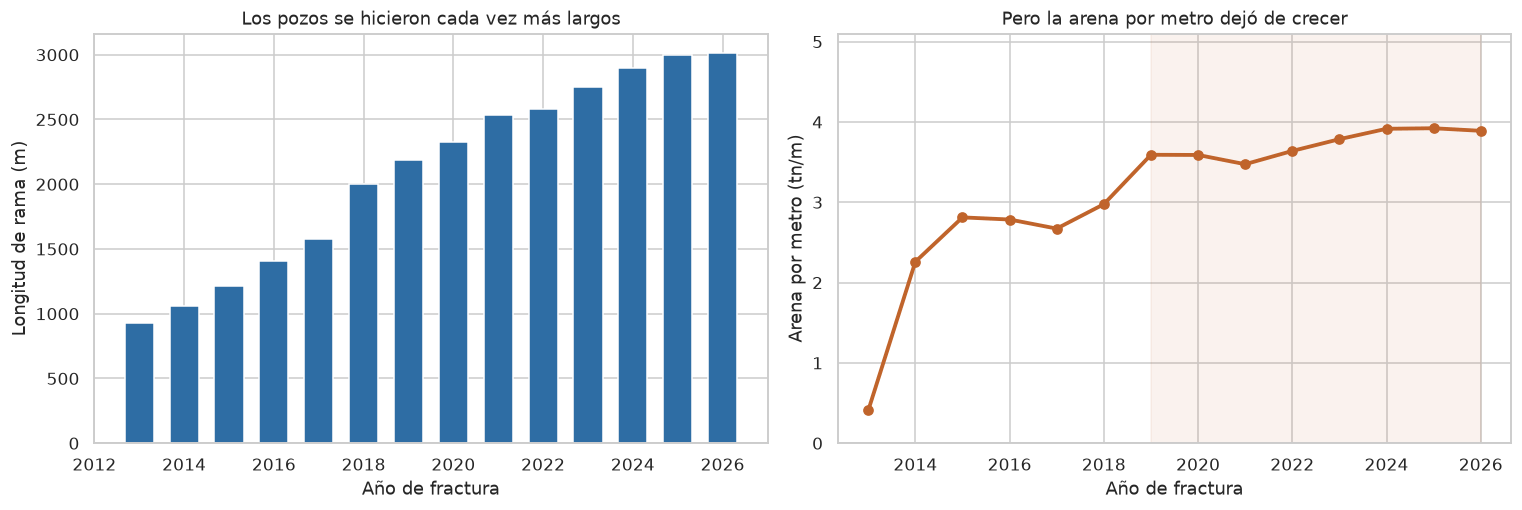

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].bar(evolucion.index, evolucion["rama"], color="#2E6DA4", width=0.65)
axes[0].set_title("Los pozos se hicieron cada vez más largos", fontsize=12)
axes[0].set_ylabel("Longitud de rama (m)")
axes[0].set_xlabel("Año de fractura")

axes[1].plot(evolucion.index, evolucion["arena_por_metro"], marker="o",
             color="#C0642B", linewidth=2.5)
axes[1].set_ylim(0, evolucion["arena_por_metro"].max() * 1.3)
axes[1].axvspan(2019, evolucion.index.max(), color="#C0642B", alpha=0.08)
axes[1].set_title("Pero la arena por metro dejó de crecer", fontsize=12)
axes[1].set_ylabel("Arena por metro (tn/m)")
axes[1].set_xlabel("Año de fractura")

plt.tight_layout()
plt.show()

> **Hallazgo — la intensidad de fractura se amesetó.**
>
> Los dos gráficos cuentan historias distintas. La rama creció sin parar: de menos de 1.000 m a
> cerca de 3.000. Pero la arena **por metro** creció fuerte hasta 2019 y desde entonces quedó casi
> igual, mientras el espaciamiento entre etapas se apretaba.
>
> La industria dejó de mejorar bombeando más arena por metro y pasó a alargar el pozo y poner las
> etapas más juntas. La lectura más probable es que subir la intensidad dejó de rendir: es
> exactamente la hipótesis que el modelo de la próxima etapa tendría que contrastar.

# Conclusiones

## Sobre la calidad de los datos

- **El dataset mezcla dos tecnologías.** El 42% de los registros son pozos verticales, con una
  escala de operación dos órdenes de magnitud menor. Analizarlos juntos no describiría a ninguno de
  los dos, así que el trabajo se acotó a los horizontales.
- **Los ceros son el problema, no los nulos.** Solo tres columnas tienen faltantes declarados, pero
  hay ceros imposibles en presión, potencia y agua, y un valor de relleno de 3 metros repetido 63
  veces en la longitud de rama.
- **El grano no es un pozo por fila.** 4.890 filas para 4.646 pozos: los excedentes son cargas
  parciales de una misma operación y hubo que sumarlas, no borrarlas.
- **Hay columnas redundantes:** `mes` repite a `mes_if` y `anio` a `anio_if`.
- **El CO2 se usó solo en pozos verticales**, así que dentro de la población analizada no aporta
  nada.

Resultado: **2.603 pozos horizontales limpios**, en su gran mayoría de Vaca Muerta.

## Sobre las variables

- Las variables crudas de diseño están muy correlacionadas entre sí —longitud con arena y con
  etapas, 0,91— porque todas crecen con el tamaño del pozo. Por eso se construyeron variables de
  **intensidad**, que son comparables entre pozos de distinto largo.
- Se crearon 12 variables nuevas de intensidad, que son las que permiten comparar pozos de
  distinto tamaño.

## Sobre el negocio

- **El diseño de pozo cambió radicalmente en una década**: la rama se triplicó y las etapas se
  multiplicaron por siete.
- **Pero la intensidad se amesetó desde 2019.** El crecimiento reciente vino de alargar el pozo y
  apretar las etapas, no de bombear más arena por metro. Sugiere que subir la intensidad llegó a un
  punto de rendimientos decrecientes.
- **Cada operadora tiene una estrategia identificable**, y se distinguen tanto por su mediana como
  por su dispersión: algunas repiten una receta estandarizada y otras deciden pozo por pozo.

## Limitaciones

- **La actividad está concentrada en pocos actores**: YPF sola tiene más pozos horizontales que las
  otras cinco operadoras principales juntas, así que las conclusiones reflejan sobre todo su forma
  de trabajar.
- **También está concentrada geológicamente**: casi todo es Vaca Muerta, y no se extrapola a otras
  formaciones.
- **El diseño está confundido con la geología.** Cada operadora trabaja en áreas de distinta calidad
  de roca, así que el efecto del diseño se mezcla con el de la roca. Este análisis describe
  asociaciones, no relaciones causales.
- **No hay contrafactual.** Solo existen los pozos que se perforaron: no se puede saber qué habría
  producido uno con otro diseño.
- **Los datos son preliminares**: la Secretaría los publica sujetos a revisión, y el año en curso
  está incompleto.

# Guardado del dataset procesado

Guardamos el dataset limpio y enriquecido, con las categóricas como texto para que siga siendo
legible. Es el punto de partida de la próxima etapa.

In [43]:
PROC_DIR.mkdir(parents=True, exist_ok=True)

d.to_csv(PROC_DIR / "pozos_analitico.csv", index=False)

print(f"pozos_analitico.csv  ->  {d.shape[0]:,} pozos x {d.shape[1]} columnas")
print(f"\nRuta: {PROC_DIR}")

pozos_analitico.csv  ->  2,603 pozos x 32 columnas

Ruta: ../data/processed
